# Social Data Analysis and Visualization (02806) - Assignment 1

## Group 70

| Parts                     | Contributor                 |
| ------------------------- | --------------------------- |
| Assignment 1.1, 1.2, 1.3: | Brynjar Bjarkason (s253549) |
| Assignment 1.4:           | Adam Ajane (s211048)        |
| Assignment 1.5:           | Sævar Reynisson (s260166)   |

## Imports


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import scipy.stats as stats
from itertools import combinations

plt.rcParams["font.family"] = "Dejavu Serif"

## Assignment 1.1: Temporal Overview

We begin by examining how each of our ten Personal Focus Crimes has evolved year-by-year from 2003 to 2025. This gives us a high-level picture of long-term trends and the impact of major events such as the COVID-19 pandemic.


In [62]:
# Read focus crime data
data = pd.read_csv("../data/sf_crime_merged_focus_2003_2025.csv")
data["Focus Crime"].unique()

<StringArray>
[ 'Vehicle Theft',        'Assault', 'Missing Person',          'Fraud',
        'Robbery',      'Vandalism',       'Burglary',   'Drug Offense',
        'Weapons',   'Prostitution']
Length: 10, dtype: str

Below, we plot the annual incident count for each Focus Crime in its own subplot. This allows us to spot crime-specific trends that would be hidden in an aggregate view.


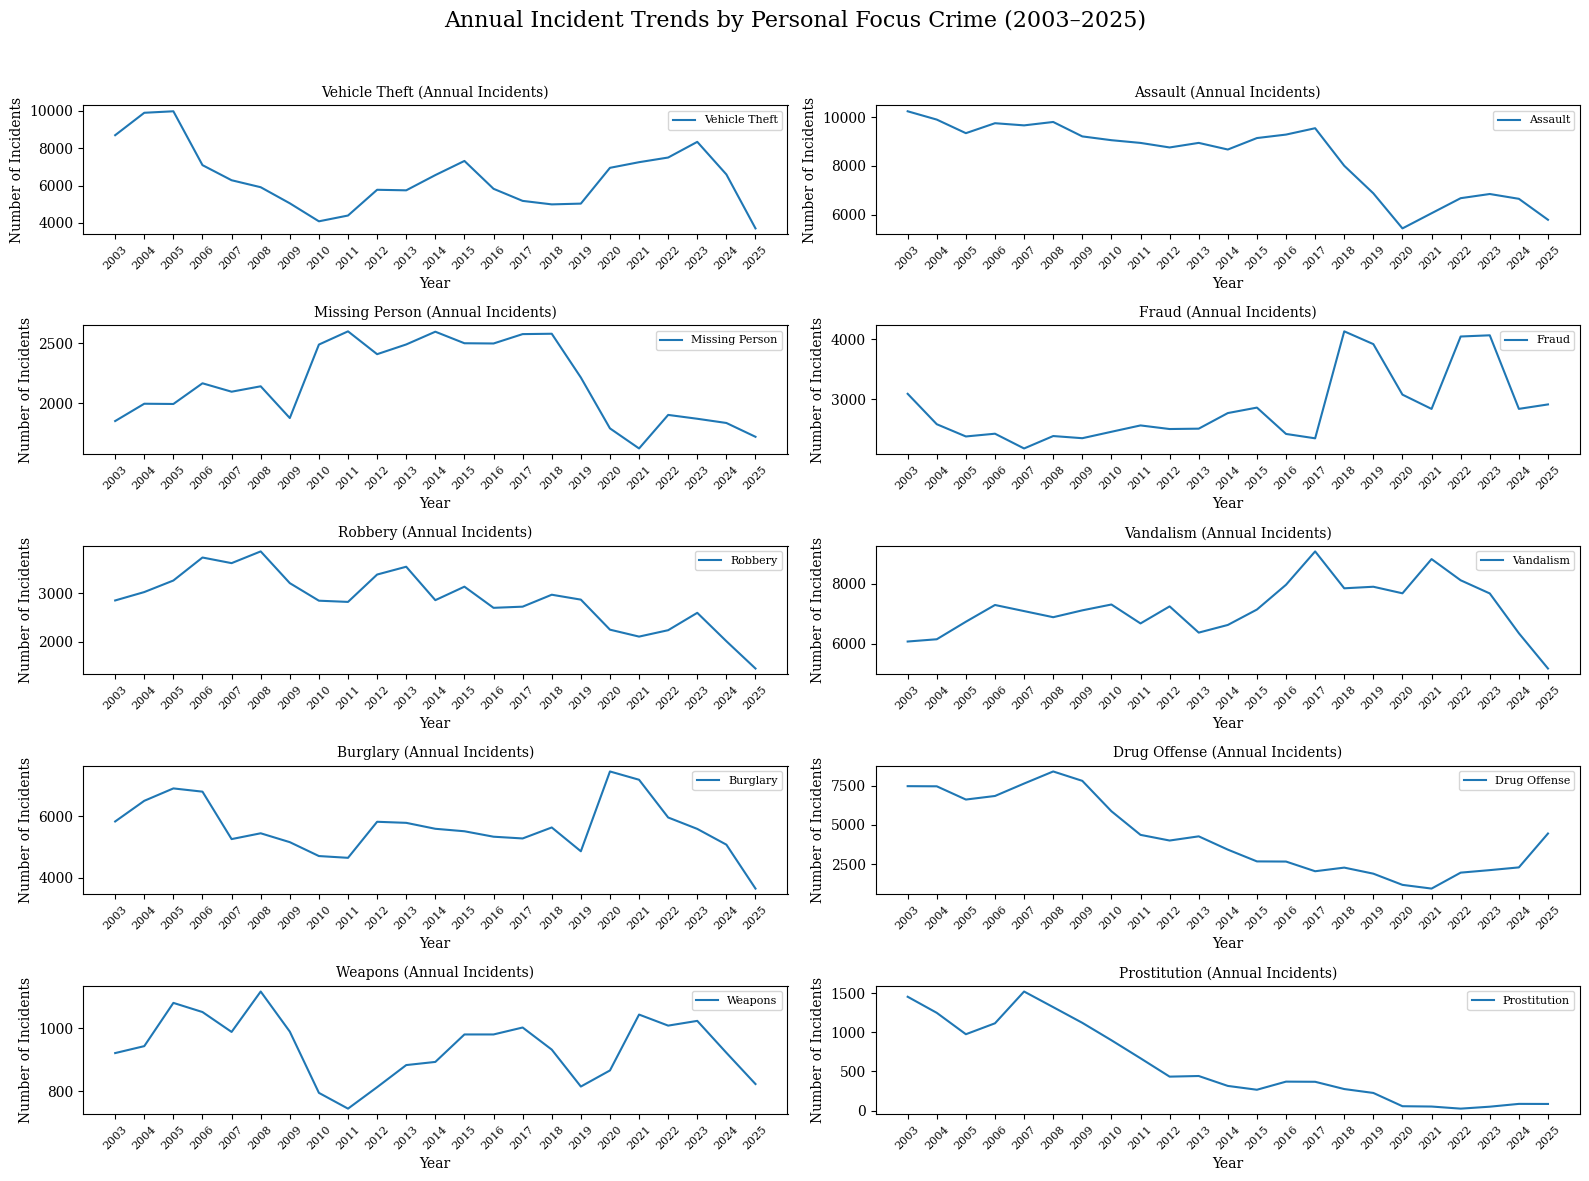

In [63]:
fig, axes = plt.subplots(5, 2, figsize=(16, 12), sharex=False, sharey=False)
axes = axes.flatten()

focus_crimes = data["Focus Crime"].unique()

# Parse to datetime to datetime
data["Incident Date"] = pd.to_datetime(data["Incident Date"])

# Don't include 2026
data = data[data["Incident Date"].dt.year != 2026]

# for loop to create a line graph for each focus crime
for ax, crime in zip(axes, focus_crimes):

    # Get counts of focus crime per year
    counts = (
        data[data["Focus Crime"] == crime].groupby(data["Incident Date"].dt.year).size()
    )

    counts.plot(ax=ax, label=crime)

    # Set every year on the x-axis
    years = counts.index
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, fontsize=8)

    ax.set_title(crime, fontsize=10)
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Incidents")

    ax.legend(fontsize=8)

    ax.set_title(f"{crime} (Annual Incidents)", fontsize=10)

fig.suptitle("Annual Incident Trends by Personal Focus Crime (2003–2025)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Partial Conclusion

It seems like most crimes have had ups and downs and especially during covid, however one notable thing is that drug offense and prostitution have been on a steep decline since around 2007-2008, a possible explanation for this would be decriminalizations for these crimes so fewer incidents are registered.

Another notable feature is that during covid around 2019-2021, most crime types either happened dramatically less often like assault (probably due to social restrictions such), or followed their previous trend, however burglary actually went up quite a bit. A theory for why this could be the case is that during covid there was higher unemployment rate leaving people with reduced financial income. As a result of that, some individuals might have felt more financial pressure, which might have resulted in an increase of these types of crimes.


## Assignment 1.2: Crime Profiles by Police District

To understand how crime composition varies across the city, we compute the ratio $\frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$ for every combination of Focus Crime and Police District. A value above 1 means the crime is overrepresented in that district relative to the city-wide average; below 1 means it is underrepresented.


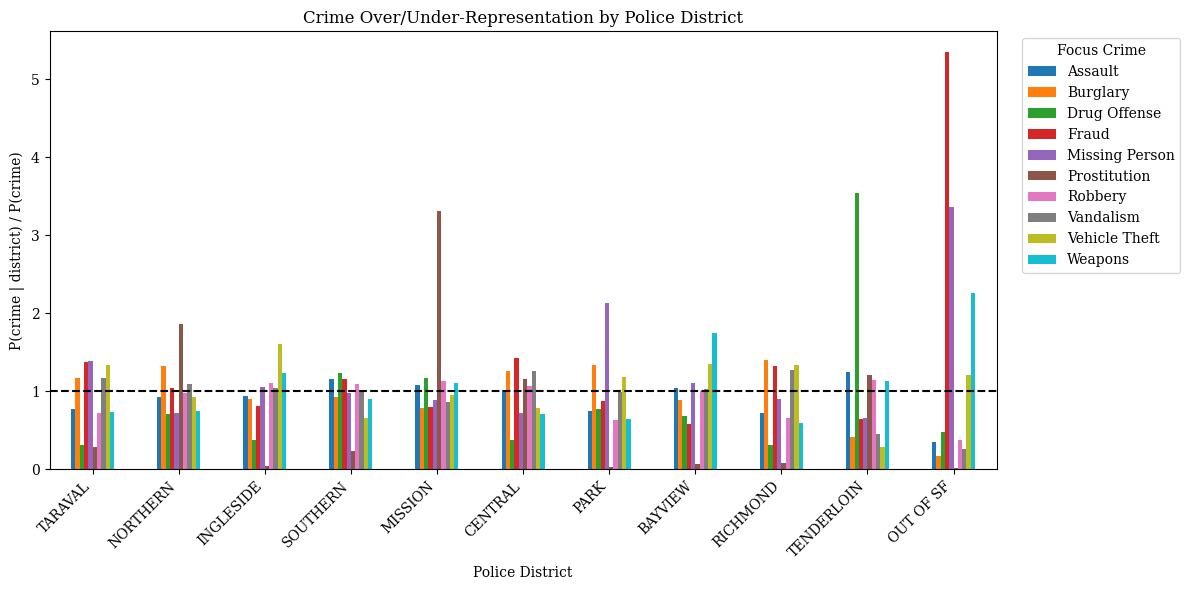

In [64]:
# Divide the count on each focus crime without the total count to get p(crime)
p_crime = data["Focus Crime"].value_counts() / len(data)

# initalize an empty array to keep track of each p(crime|district)
p_crime_district = []
for district in data["Police District"].str.upper().unique():
    # nr of total crimes in a district
    nr_of_total_crimes = len(data[data["Police District"].str.upper() == district])

    # nr of a focus crime in a district
    nr_of_crimes = data[data["Police District"].str.upper() == district][
        "Focus Crime"
    ].value_counts()

    # Calculate p(crime|district) / p(crime) for each district
    p_crime_district.append((nr_of_crimes / nr_of_total_crimes) / p_crime)


# combine the data to a dataframe for plotting
df_combined = pd.concat(p_crime_district, axis=1)

# Assign district names as column labels
df_combined.columns = data["Police District"].str.upper().unique()

# Make sure the index is the crime names (optional but nice)
df_combined.index.name = "Focus Crime"

df_plot = df_combined.T

ax = df_plot.plot(kind="bar", figsize=(12, 6))

plt.axhline(y=1, color="black", linestyle="--", linewidth=1.5)

plt.xlabel("Police District")
plt.ylabel("P(crime | district) / P(crime)")
plt.title("Crime Over/Under-Representation by Police District")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Focus Crime", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Partial Conclusion

We decided to visualize this with grouped bar charts, where each group is a police district and each bar in a group is a crime. We did that because you can easily see which crimes are over/under represented in a district just by looking at the district on the x-axis, as well as easily spot which how the representation of crimes differ per district.

The district we wanted to look at is Park. It has high overrepresentation of missing person compared to other district. Burglary and vehicle theft are also overrepresented in Park and prostitution is heavily underrepresented in Park.

According to the [San Francisco Police Department](https://www.sanfranciscopolice.org/stations/park-station) the neighbourhoods included in Park are the vast eastern edge of Golden Gate Park and the world-famous neighborhoods of Haight-Ashbury and the Castro. Seeing as Golden Gate Park is part of that district, a theory to explain missing persons as well as vehicle theft, since there is a lot of people coming through there with their guard down. Regarding low prostitution rate compared to other districts, 4 districts that have higher prostitution and 2 of them way higher, so a theory could be that prostitution may concentrate in particular hotspot areas, and the Park district has no such area.

## Assignment 1.3: Visualizing Distributions

In this section we explore the distributional properties of our crime data using three complementary techniques: a jitter plot to inspect reporting-time granularity, QQ plots to compare spatial distributions against the normal distribution, and box plots to summarize time-of-day patterns.


### Part A: Jitter Plot

We filter Assault incidents to a single one-hour window (14:00–15:00) over the last four months and jitter them vertically. This reveals whether incident times are recorded at precise timestamps or rounded to fixed intervals.


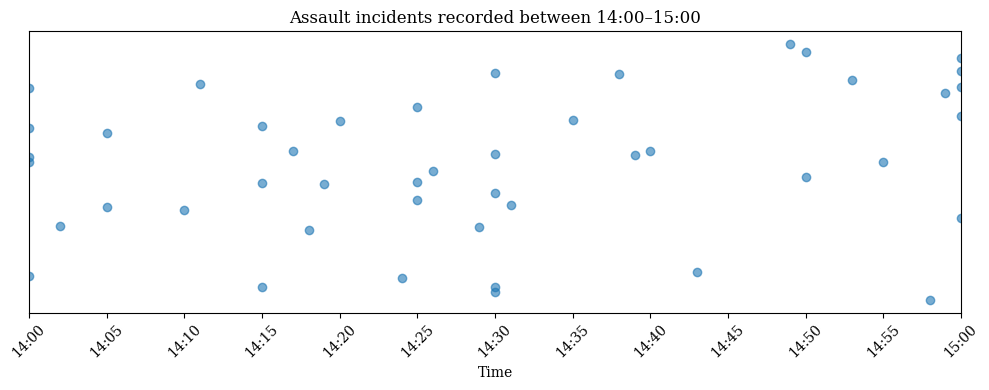

In [65]:
# Part A
# only data for the last 4 months
new_data = data.loc[data["Focus Crime"].eq("Assault")].copy()
four_months_ago = pd.Timestamp.now() - pd.DateOffset(months=4)

new_data["Incident Date"] = pd.to_datetime(new_data["Incident Date"], errors="coerce")
new_data = new_data.loc[new_data["Incident Date"] >= four_months_ago].copy()

# Parse incident time to datetime (to use it as hours)
new_data["Incident Time"] = pd.to_datetime(
    "2000-01-01 " + new_data["Incident Time"].astype(str), errors="coerce"
)

# drop rows that don't have incident time
new_data = new_data.dropna(subset=["Incident Time"])

# using only data between 14 and 15, one hour interval
hour_start = pd.Timestamp("2000-01-01 14:00:00")
hour_end = pd.Timestamp("2000-01-01 15:00:00")

one_hour = new_data[
    (new_data["Incident Time"] >= hour_start) & (new_data["Incident Time"] <= hour_end)
].copy()


# adds vertical jitter to point
def add_jitter(n, scale=0.2):
    return np.random.uniform(-scale, scale, size=n)


one_hour["jitter"] = add_jitter(len(one_hour))

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(one_hour["Incident Time"], one_hour["jitter"], alpha=0.6)

ax.set_xlabel("Time")
ax.set_ylabel("")
ax.set_yticks([])

ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax.set_xlim(hour_start, hour_end)

plt.title("Assault incidents recorded between 14:00–15:00")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From the jitter plot it can be seen that there do form clusters in 30 minute intervals and in some cases around a 5 minute interval, such as 14:40 and 14:25. From this we can assume that most incidents are registered at a time interval close to when the incident happen, and some up to 30 minutes. This means that the data is not 100% precise up to the minute so there needs to be caution when working with the incident times, especially if they need to be 100% precise.


### Part B: Probability Plot

We use QQ (quantile-quantile) plots to compare the latitude distribution of Assault and Prostitution incidents against a theoretical normal distribution. Deviations from the diagonal indicate clustering at specific latitudes.


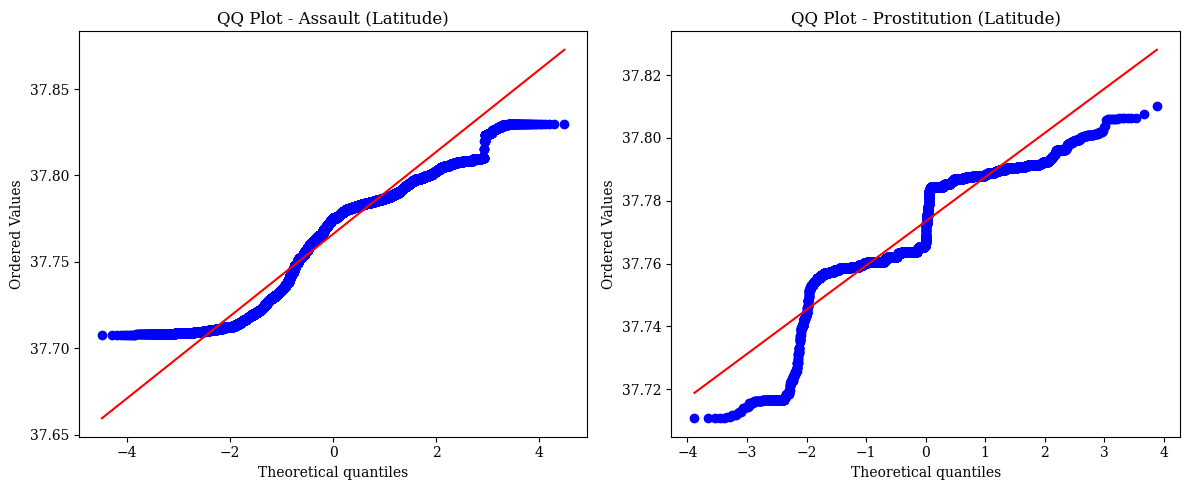

In [66]:
# Part B
# some values were 90, probably outliers, so only get ones under 50
data_clean = data[data["Latitude"] < 50]

# Look at assault and prostitution
assault_lat = data_clean[data_clean["Focus Crime"] == "Assault"]["Latitude"]
prostitution_lat = data_clean[data_clean["Focus Crime"] == "Prostitution"]["Latitude"]

# Create QQ plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Assault QQ plot
stats.probplot(assault_lat, dist="norm", plot=axes[0])
axes[0].set_title("QQ Plot - Assault (Latitude)")

# Prostitution QQ plot
stats.probplot(prostitution_lat, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot - Prostitution (Latitude)")

plt.tight_layout()
plt.show()

With the QQ plots we are comparing the latitude distribution of assault and prostitution to a normal distribution.
The more that the data follows the line, the more normally distributed is it, so if it would lie perfectly on the line it would follow a perfect normal distribution. However that is not the case for assault nor prostitution, assault has a long flat line at the bottom which can be explained by Bayview, which has an overrepresentation of assault falling on that latitude line, then around 37.8 - 38.0 degrees there are a lot of assaults which could be explained the same way with districts that have comparatively high assault rates such as Tenderloin, Mission and Southern falling around this latitude. Lastly there is a flat line around 38.2 degrees which is exactly the latitude of Treasure Island which seems to have higher crime rates compared to other neighbourhoods ([source](https://www.doorprofit.com/crime-map/city/san_francisco-CA/neighborhood/treasure-island/)).

The distribution of prostitution follows the same pattern and has 3 distinct lines. Around 37.70 degrees, 37.76 degrees and 37.78-37.80 degrees. When looking at section 1.2 we can see that districts where prostitution is overrepresented fall directly on these latitude lines, Mission district at 37.76, Northern district and Tenderloin at 37.78, Central district 37.798. Latitude numbers found on [Google Maps](https://www.google.com/maps).

So what this tells us about SF's crime geography is that it clusters and is concentrated in specific districts rather than being spread evenly around the city.

### Part C: Box Plots of Time-of-Day

Finally, we create box plots of the reporting hour for all ten Focus Crimes. This shows median reporting time, spread, and outliers, and helps identify which crimes are predominantly daytime vs. nighttime phenomena.


/var/folders/vq/hbwc6_v92sg0d1qr62bc4_800000gn/T/ipykernel_50839/1485925094.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(incident_times, labels=titles)


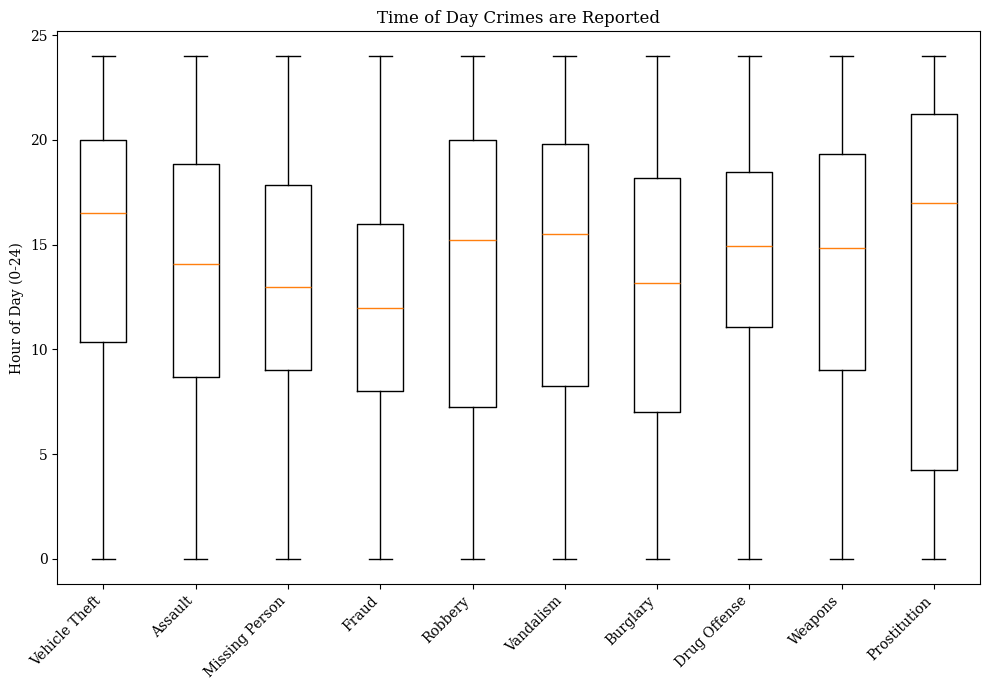

In [67]:
# Part C
titles = []
incident_times = []

for crime in data["Focus Crime"].unique():
    crime_data = data[data["Focus Crime"] == crime].copy()
    crime_data["Incident Time"] = pd.to_datetime(
        "2000-01-01 " + crime_data["Incident Time"], errors="coerce"
    )

    # Convert to hours since midnight (numeric)
    numeric_times = (
        crime_data["Incident Time"].dt.hour + crime_data["Incident Time"].dt.minute / 60
    )
    incident_times.append(numeric_times)
    titles.append(crime)

fig = plt.figure(figsize=(10, 7))
plt.boxplot(incident_times, labels=titles)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Hour of Day (0-24)")
plt.title("Time of Day Crimes are Reported")
plt.tight_layout()
plt.show()

The median for most crimes are around 12-18, although they happen all the way from 0-23:59, there are crimes that peak at night such as prostitution but the box plot does not handle the midnight wrap-around well, because crimes that happen during 23 PM and 1 AM stretch out the whole boxplot even though they are close together, which causes the median to go near the center.


### Partial Conclusion

The three visualizations each highlight a different facet of how crime data is distributed. The jitter plot reveals that incident times cluster at round intervals (multiples of 5 and 30 minutes), meaning the recorded timestamps carry limited precision and should be treated with caution in fine-grained analyses. The QQ plots show that crime latitude distributions deviate substantially from normality, with clear plateaus at the latitudes of high-crime districts like Tenderloin, Mission, and Bayview — confirming the spatial concentration already hinted at in Assignment 1.2. The box plots show that most crime types peak during daytime and afternoon hours, with notable exceptions such as prostitution which skews toward nighttime. However, the box plot representation struggles with the midnight wrap-around, which can misrepresent crimes that span late-night and early-morning hours.


## Assignment 1.4: Spatial Power Law

For this part, we're interested in examining whether crime is evenly spread throughout the city of San Francisco, or if it's concentrated in hotspots.

The basis of our crime analysis is **Assault** as it's our Personal Focus Crime with the highest total incident count.

In [68]:
# Load data (only the columns we need)
data = pd.read_csv(
    "../data/sf_crime_merged_focus_2003_2025.csv",
    usecols=["Focus Crime", "Latitude", "Longitude"],
)

# Filter to Assault
assault = data[data["Focus Crime"] == "Assault"].copy()
assault = assault.dropna(subset=["Latitude", "Longitude"])

# Bounding box for SF peninsula (filter geographic outliers)
lat_min, lat_max = 37.70, 37.83
lon_min, lon_max = -122.52, -122.35

assault = assault[
    (assault["Latitude"] >= lat_min)
    & (assault["Latitude"] <= lat_max)
    & (assault["Longitude"] >= lon_min)
    & (assault["Longitude"] <= lon_max)
]

print(f"Assault incidents after filtering: {len(assault):,}")

Assault incidents after filtering: 193,078


### Steps 1–3: Grid, Count, and Tally

As our point of depature, we divide SF into a grid of approximately $100\mathrm{m} \times 100\mathrm{m}$ cells. At SF's latitude (~37.77°N):

- 1° latitude ≈ 111 km → 100 m ≈ 0.0009°
- 1° longitude ≈ 111 km × cos(37.77°) ≈ 87.7 km → 100 m ≈ 0.00114°

We use `np.histogram2d` to bin all Assault incidents into grid cells, then tally how many cells have exactly _k_ incidents.


In [69]:
# Step 1: Create ~100m x 100m grid
deg_per_100m_lat = 0.0009
deg_per_100m_lon = 0.00114

n_lat_bins = int(np.ceil((lat_max - lat_min) / deg_per_100m_lat))
n_lon_bins = int(np.ceil((lon_max - lon_min) / deg_per_100m_lon))

print(
    f"Grid size: {n_lat_bins} lat bins x {n_lon_bins} lon bins = {n_lat_bins * n_lon_bins:,} cells"
)

# Step 2: Count incidents per cell
counts_2d, lat_edges, lon_edges = np.histogram2d(
    assault["Latitude"].values,
    assault["Longitude"].values,
    bins=[n_lat_bins, n_lon_bins],
    range=[[lat_min, lat_max], [lon_min, lon_max]],
)

# Step 3: Tally the distribution — N(k) = number of cells with exactly k incidents
cell_counts = counts_2d.flatten().astype(int)
N_k = np.bincount(cell_counts)  # N_k[k] = number of cells with exactly k incidents
k_values = np.arange(len(N_k))

print(f"Max incidents in a single cell: {cell_counts.max()}")
print(
    f"Cells with 0 incidents: {N_k[0]:,} out of {len(cell_counts):,} ({N_k[0]/len(cell_counts)*100:.1f}%)"
)
print(f"Cells with ≥1 incident: {(cell_counts > 0).sum():,}")

Grid size: 145 lat bins x 150 lon bins = 21,750 cells
Max incidents in a single cell: 3459
Cells with 0 incidents: 13,760 out of 21,750 (63.3%)
Cells with ≥1 incident: 7,990


We observe that the majority $(63.3\%)$ of the city cells have no incidents of Assault, suggesting that incidents occur in concentrated city regions. $36.7\%$ of cells have at least 1 or more incident of Assault.

### Step 4: Linear plot

Next, we plot the distribution of Assault incidents per grid cell, with number of incidents $k + 1$ on the x-axis, and number of cells $N(k)$ on the y-axis. In our plotting, we use linear axes.

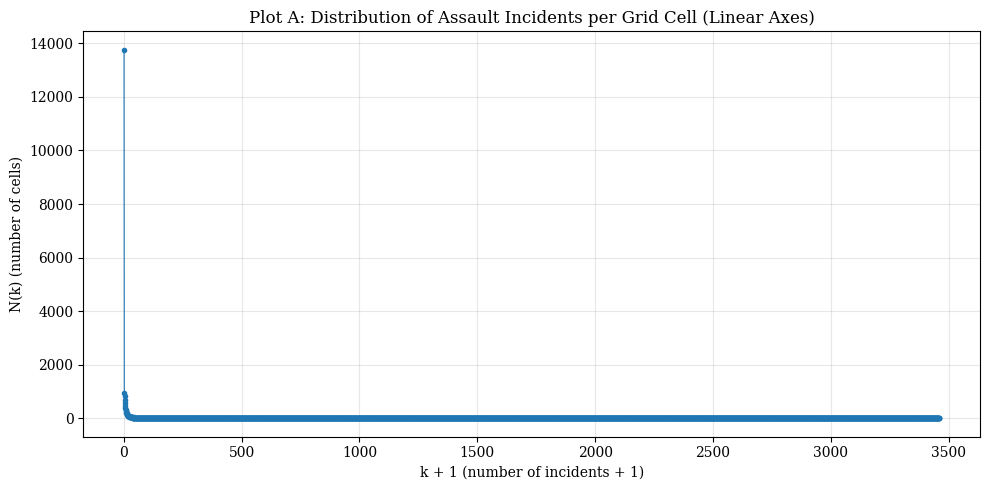

In [70]:
# Step 4: Plot (k+1) vs N(k) on linear axes
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values + 1, N_k, "o-", markersize=3, linewidth=0.8)
ax.set_xlabel("k + 1 (number of incidents + 1)")
ax.set_ylabel("N(k) (number of cells)")
ax.set_title("Plot A: Distribution of Assault Incidents per Grid Cell (Linear Axes)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 5: Log-log plot

To test for a power law, we re-plot the same distribution on logarithmic axes. If the relationship is a true power law, i.e. $N(k) \propto (k+1)^{-\alpha}$, the data should appear as a straight line on a log-log plot. We exclude cells where $N(k) = 0$, since the logarithm is undefined there.


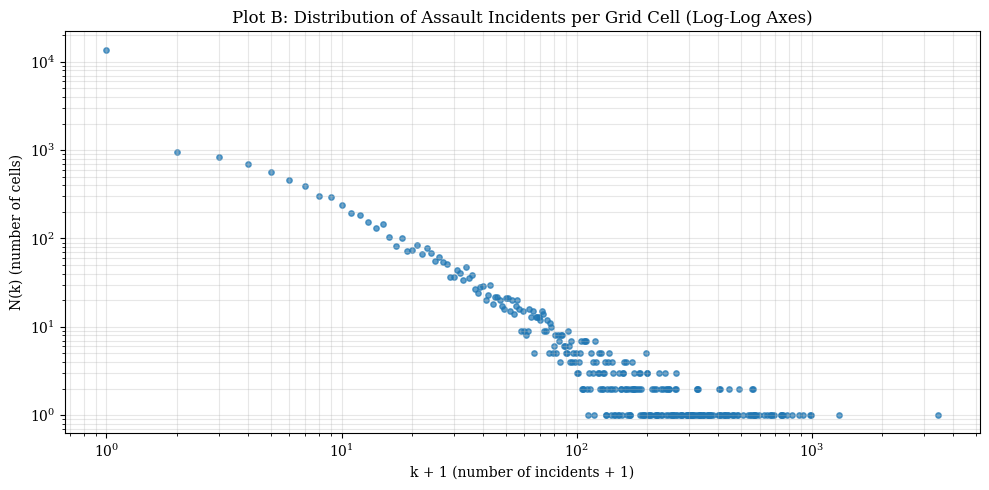

In [71]:
# Step 5: Plot (k+1) vs N(k) on log-log axes
# Filter out k values where N(k) == 0 (can't plot log of 0)
mask = N_k > 0

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(k_values[mask] + 1, N_k[mask], s=15, alpha=0.7)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("k + 1 (number of incidents + 1)")
ax.set_ylabel("N(k) (number of cells)")
ax.set_title("Plot B: Distribution of Assault Incidents per Grid Cell (Log-Log Axes)")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### Step 6: Does Assault follow a power-law spatial distribution?

The data is consistent with a power-law distribution. On the linear plot (**Plot A**), we see a dominant spike at $k = 0$ (most cells are empty) followed by a long, heavy tail extending to cells with thousands of incidents. On the log-log plot (**Plot B**), the data follows an approximately straight line from the upper-left to the lower-right across several orders of magnitude, which is the key pattern for a power law $N(k) \propto (k+1)^{-\alpha}$. There is some scatter and mild curvature at the high-$k$ tail, which is expected for real-world data, but the overall pattern is well-described by a power law.

### Step 7: Implications of spatial concentration

The power-law distribution reveals a notable spatial inequality. 63% of grid cells recorded zero incidents of Assault, while a small number of hotspot cells accumulated thousands of cases. This means the "average block" crime rate of ${\sim}9$ incidents per $100\mathrm{m}$ cell is deeply misleading. The mean is dominated by a handful of extreme locations and tells us little about the typical crime rate of any given block. For neighborhood-level statistics, this implies that aggregate crime rates can conceal extreme local variation. From a policing and resource-allocation perspective, it suggests that concentrating personnel on the small fraction of hotspot cells could address a large share of total incidents.

### Partial Conclusion

Assault incidents across San Francisco are not distributed evenly in space. They are heavily concentrated in a small number of $100\mathrm{m} \times 100\mathrm{m}$ hotspot cells, with the vast majority of the city's grid cells recording no incidents. The distribution of incidents per cell follows an approximate power law, visible as a straight-line decay on log-log axes. This spatial difference means that city-wide or district-level averages conceal extreme local variation, and that more localized police interventions are likely to be more effective than city-wide approaches.


## Assignment 1.5: Regression and Correlation

We investigate whether different crime types share similar weekly rhythms by building a 168-hour (7 days × 24 hours) activity vector for each crime and computing pairwise linear regressions. For each pair we report the Pearson correlation $r$ and the coefficient of determination $R^2$.


In [72]:
SELECTED_CRIMES = [
    "Assault",
    "Robbery",
    "Fraud",
    "Prostitution",
]  # Selected crimes for this part
N_COLS = 3  # Number of columns in the plot
N_ROWS = 2  # Number of rows in the plot

In [73]:
# Helper functions


def linear_fit_closed_form(x, y):
    """
    Fit y = a*x + b with closed-form least squares; return (a, b) based on equations (1) and (2) from week 4, or (nan, nan) if x has zero variance.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    x_mean = x.mean()
    y_mean = y.mean()

    numerator = np.sum(x * y) - n * x_mean * y_mean
    denominator = np.sum(x * x) - n * x_mean * x_mean

    if denominator == 0:
        return np.nan, np.nan

    a = numerator / denominator
    b = y_mean - a * x_mean
    return a, b


def r2_from_fit(x, y, a, b):
    """
    Compute R^2 for y_hat = a*x + b based on equations on Coefficient of Determination Wikipedia page; return NaN if fit params are invalid or y has zero variance.
    """
    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y_hat = a * x + b

    ssres = np.sum((y - y_hat) ** 2)
    sstot = np.sum((y - y.mean()) ** 2)

    if sstot == 0:
        return np.nan

    return 1 - ssres / sstot

In [74]:
df = pd.read_csv(
    "../data/sf_crime_merged_focus_2003_2025.csv",
    usecols=["Focus Crime", "Incident Date", "Incident Time"],
)

# Build 168-hour weekly vectors per crime
df = df[df["Focus Crime"].isin(SELECTED_CRIMES)].copy()  # Only keep selected crimes
df["Incident Date"] = pd.to_datetime(
    df["Incident Date"], errors="coerce"
)  # Convert date text to real dates

# Extract hour from Incident Time, drop invalid rows and create HourOfWeek column
hour_str = df["Incident Time"].astype(str).str.extract(r"^(\d{1,2})")[0]
df["Hour"] = pd.to_numeric(hour_str, errors="coerce")
df = df.dropna(subset=["Incident Date", "Hour"])
df["Hour"] = df["Hour"].astype(int).clip(0, 23)
df["HourOfWeek"] = df["Incident Date"].dt.dayofweek * 24 + df["Hour"]

# Count number of incidents for a crime per hour
hourly_168 = (
    df.groupby(["HourOfWeek", "Focus Crime"]).size().rename("Count").reset_index()
)

# Create a table with the number of incidents for each crime per hour
pivot = (
    hourly_168.pivot(index="HourOfWeek", columns="Focus Crime", values="Count")
    .reindex(range(168))
    .fillna(0)
    .reindex(columns=SELECTED_CRIMES, fill_value=0)
)

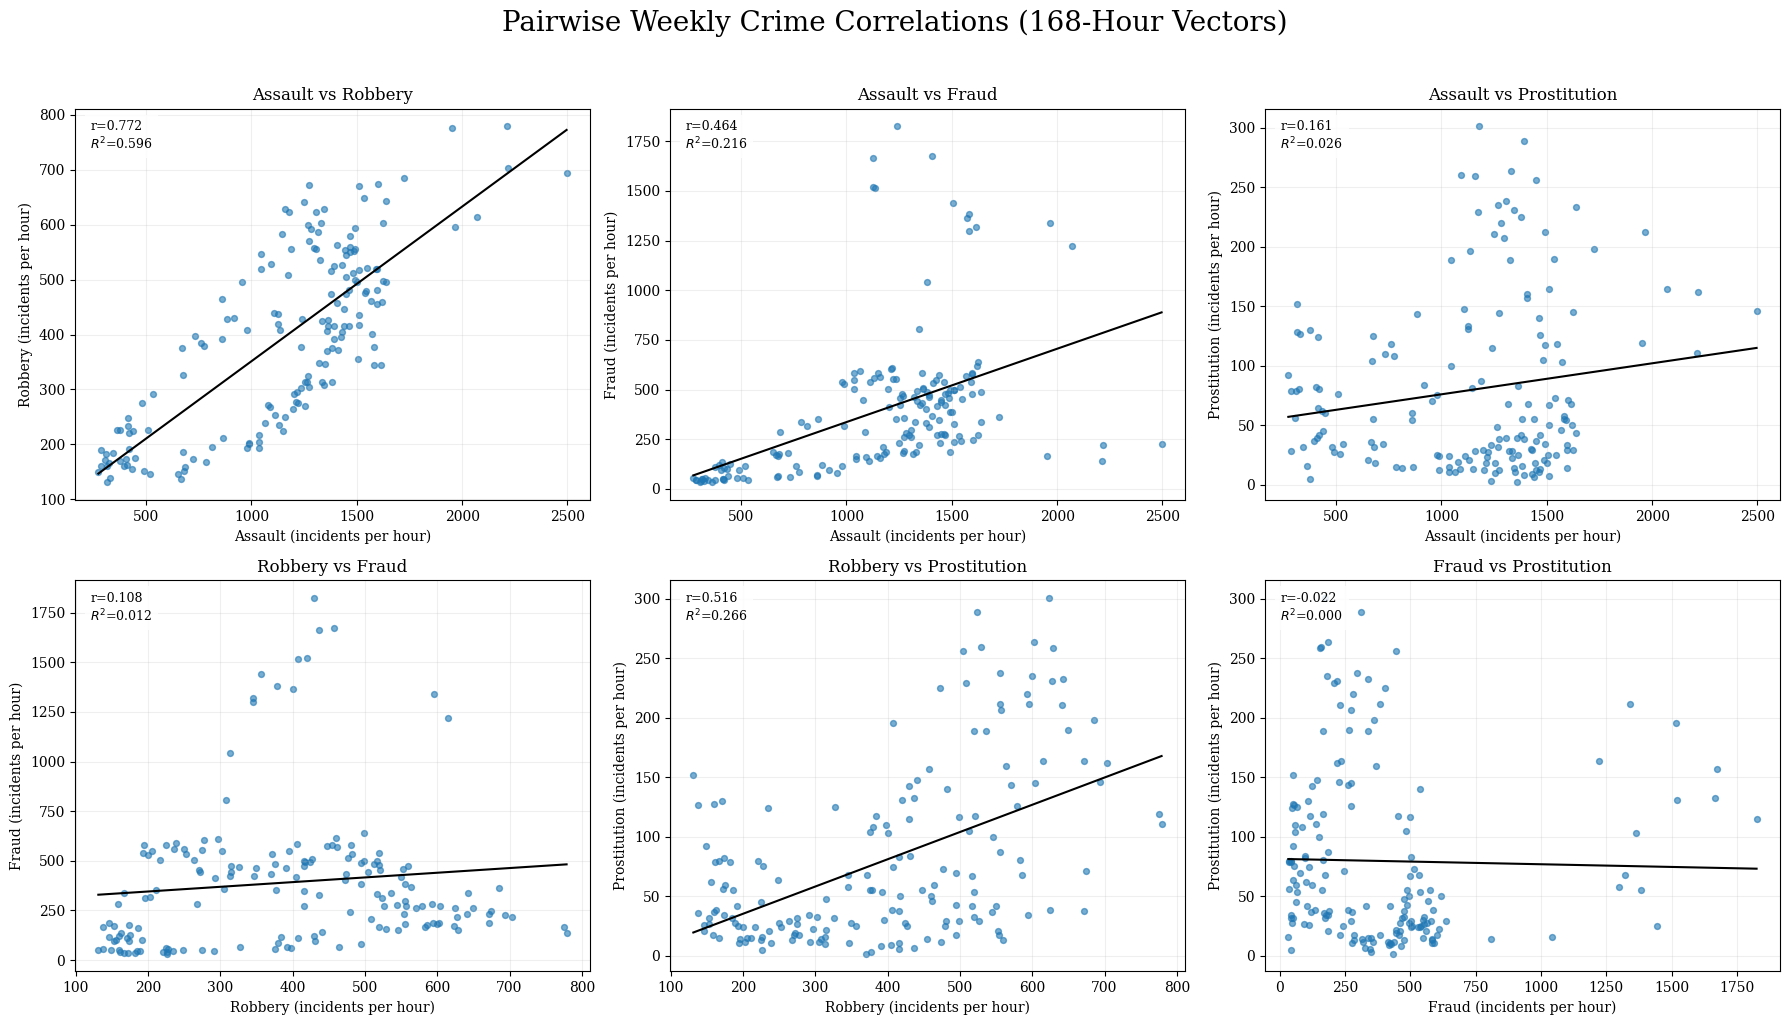

Pairwise results (sorted by R^2):
Crime A      Crime B      r    R2  a_slope  b_intercept
Assault      Robbery  0.772 0.596    0.282       69.819
Robbery Prostitution  0.516 0.266    0.229      -10.291
Assault        Fraud  0.464 0.216    0.369      -33.325
Assault Prostitution  0.161 0.026    0.026       49.839
Robbery        Fraud  0.108 0.012    0.236      298.423
  Fraud Prostitution -0.022 0.000   -0.005       81.565

Most correlated pair:
- Assault vs Robbery | r=0.772, R^2=0.596

Least correlated pair:
- Fraud vs Prostitution | r=-0.022, R^2=0.000


In [75]:
# Create a list of all possible pairs of crimes and set up the plot
pairs = list(combinations(SELECTED_CRIMES, 2))
n_pairs = len(pairs)
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(6 * N_COLS, 5 * N_ROWS))
axes = np.atleast_1d(axes).ravel()
fig.suptitle("Pairwise Weekly Crime Correlations (168-Hour Vectors)", fontsize=20, y=1.02)

rows = []  # List to store the results

# Loop through each pair of crimes and plot the scatterplot and regression line
for ax, (crime_x, crime_y) in zip(axes, pairs):
    x = pivot[crime_x].to_numpy()  # Convert the crime_x column to a numpy array
    y = pivot[crime_y].to_numpy()  # Convert the crime_y column to a numpy array

    # Calculate the linear fit and R^2 for the pair of crimes
    a, b = linear_fit_closed_form(x, y)
    r2 = r2_from_fit(x, y, a, b)

    # Calculate the Pearson correlation coefficient for the pair of crimes
    if np.std(x) == 0 or np.std(y) == 0:
        r = np.nan
    else:
        r = np.corrcoef(x, y)[0, 1]

    # Store the results in our list
    rows.append(
        {
            "Crime A": crime_x,
            "Crime B": crime_y,
            "a_slope": a,
            "b_intercept": b,
            "r": r,
            "R2": r2,
        }
    )

    # Plot the scatterplot
    ax.scatter(x, y, s=18, alpha=0.6, color="tab:blue")

    # Plot the regression line
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = a * x_line + b
    ax.plot(x_line, y_line, color="black", linewidth=1.5)

    # Insert correlation coefficient and R^2 text into the top left corner of the plot
    ax.text(
        0.03,
        0.97,
        f"r={r:.3f}\n$R^2$={r2:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85),
    )

    # Set the title, x-axis label, y-axis label, and grid
    ax.set_title(f"{crime_x} vs {crime_y}")
    ax.set_xlabel(f"{crime_x} (incidents per hour)")
    ax.set_ylabel(f"{crime_y} (incidents per hour)")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# Print key findings
results = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
most_correlated = results.iloc[0]
least_correlated = results.iloc[-1]

print("Pairwise results (sorted by R^2):")
print(
    results[["Crime A", "Crime B", "r", "R2", "a_slope", "b_intercept"]].to_string(
        index=False, float_format=lambda v: f"{v:.3f}"
    )
)

print("\nMost correlated pair:")
print(
    f"- {most_correlated['Crime A']} vs {most_correlated['Crime B']} "
    f"| r={most_correlated['r']:.3f}, R^2={most_correlated['R2']:.3f}"
)

print("\nLeast correlated pair:")
print(
    f"- {least_correlated['Crime A']} vs {least_correlated['Crime B']} "
    f"| r={least_correlated['r']:.3f}, R^2={least_correlated['R2']:.3f}"
)

### Partial Conclusion

Different crime types can follow different weekly patterns because they happen in different settings and are reported in different ways. Some crimes are linked more to nightlife and late hours, while others are often discovered and reported during daytime or work hours. Police focus in certain areas can also affect when incidents are recorded.

In our results, the most correlated pair is Assault vs Robbery $(R^2=0.596)$. These crimes are more similar in nature and both involve direct personal contact, so it makes sense that their weekly rhythm is relatively close. The least correlated pair is Fraud vs Prostitution $(R^2=−0.005)$, which also makes sense because these two crimes are very different in both behavior and reporting pattern.

A key conclusion is that weekly timing gives important information that total incident counts alone cannot show. Two crimes can have similar totals but completely different hourly patterns, while other crimes can move together during the same parts of the week. Because of this, understanding crime patterns requires looking at context, time-of-week behavior, and reporting dynamics, not just the raw number of incidents.
